# T-Dmap reviewed version

这个版本是在原 notebook 基础上加入几处关键修正：

1. **手动选择的 slit 端点会保存/读取**：默认文件 `selected_slit_points.csv`。如果文件存在，下次会直接读取；如果要重选，把对应 cell 里的 `force_reselect_slit = False`。
2. **手动选择的拟合点会保存/读取**：默认文件 `selected_fit_points.csv`。如果文件存在，下次会直接读取；如果要重选，把对应 cell 里的 `force_reselect_fit = True`。
3. **高度轴换算改为端点世界坐标距离**：用 `w0.separation(w1)` 得到 slit 全长，避免原来 `sqrt(scale_x**2 + scale_y**2)` 造成的约 `sqrt(2)` 放大。
4. **拟合点在拟合前按时间排序**：避免点击顺序影响初值和拟合结果。
5. **指数拟合加入基本物理约束**：限制 `c0 > 0`、`tau > 0`，并把 `t0` 固定为第一帧时间，减少非物理解和参数退化。

注意：这个版本仍然没有自动做每一帧的太阳自转/重投影校正。若事件持续数小时，并且你需要严格追踪同一个太阳结构，建议后续把 slit 的世界坐标旋转到每张 map 的观测时间，或先把序列 reproject 到共同参考帧。


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sunpy.map

from astropy.time import Time
import astropy.units as u

from skimage.measure import profile_line
from skimage.feature import canny
from scipy.optimize import curve_fit

import astropy.units as u
from astropy.coordinates import SkyCoord

from sunpy.physics.differential_rotation import solar_rotate_coordinate
import matplotlib.dates as mdates
from matplotlib.colors import LogNorm
from scipy.optimize import brentq
from pathlib import Path


In [2]:
sequence_304 = sunpy.map.Map('/Volumes/Ying_Disk/research/raw_data/pcf/2011.08.17_03_28_00_TAI/*.image_lev1.fits', sequence=True)



In [3]:

xmin=-900
xmax=300
ymin=600
ymax=1200
bottom_left = [xmin, ymin] * u.arcsec
top_right  = [xmax, ymax] * u.arcsec

x_size = xmax-xmin
y_size = ymax-ymin
map_small = sequence_304[-20].submap(SkyCoord(*bottom_left, frame=sequence_304[-20].coordinate_frame),
                          top_right=SkyCoord(*[top_right[0], top_right[1]+0.5*u.arcsec],frame=sequence_304[-20].coordinate_frame)) 


In [4]:
%matplotlib qt
example_map = sequence_304[0]

slit_points_file = Path("selected_slit_points.csv")
force_reselect_slit = False  # 改成 True 可以重新手选 slit 并覆盖保存的端点

if slit_points_file.exists() and not force_reselect_slit:
    saved_slit = np.loadtxt(slit_points_file, delimiter=",", skiprows=1)
    saved_slit = np.atleast_2d(saved_slit)
    pts = [(saved_slit[0, 0], saved_slit[0, 1]), (saved_slit[1, 0], saved_slit[1, 1])]
    print(f"Loaded slit points from {slit_points_file}:", pts)
else:
    fig = plt.figure(figsize=(8, 8))
    ax = plt.subplot(projection=example_map)
    example_map.plot(axes=ax, clip_interval=(1, 99.99)*u.percent)
    example_map.draw_limb(axes=ax)
    plt.title("Click two points to define the slit (first = lower point)")
    plt.tight_layout()

    pts = plt.ginput(n=2, timeout=0)
    plt.close(fig)

    np.savetxt(
        slit_points_file,
        np.array(pts, dtype=float),
        delimiter=",",
        header="x_pixel,y_pixel",
        comments="",
    )
    print(f"Saved slit points to {slit_points_file}")

print("Slit pixel positions:", pts)

# pts gives [(x, y), ...], while skimage.profile_line needs (row, col) = (y, x)
p0 = (pts[0][1], pts[0][0])
p1 = (pts[1][1], pts[1][0])

print("p0 (row,col):", p0)
print("p1 (row,col):", p1)

n_samples = 400


Loaded slit points from selected_slit_points.csv: [(np.float64(1373.59353020352), np.float64(3464.66219525771)), (np.float64(979.633383259287), np.float64(3972.03511177679))]
Slit pixel positions: [(np.float64(1373.59353020352), np.float64(3464.66219525771)), (np.float64(979.633383259287), np.float64(3972.03511177679))]
p0 (row,col): (np.float64(3464.66219525771), np.float64(1373.59353020352))
p1 (row,col): (np.float64(3972.03511177679), np.float64(979.633383259287))


In [5]:
(x0, y0), (x1, y1) = pts

# 转成世界坐标（helioprojective）
w0 = example_map.pixel_to_world(x0*u.pixel, y0*u.pixel)
w1 = example_map.pixel_to_world(x1*u.pixel, y1*u.pixel)

# 输出 arcsec
print("Point 1 (arcsec):", w0.Tx.to(u.arcsec), w0.Ty.to(u.arcsec))
print("Point 2 (arcsec):", w1.Tx.to(u.arcsec), w1.Ty.to(u.arcsec))

Point 1 (arcsec): -408.923 arcsec 853.398 arcsec
Point 2 (arcsec): -644.785 arcsec 1157.74 arcsec


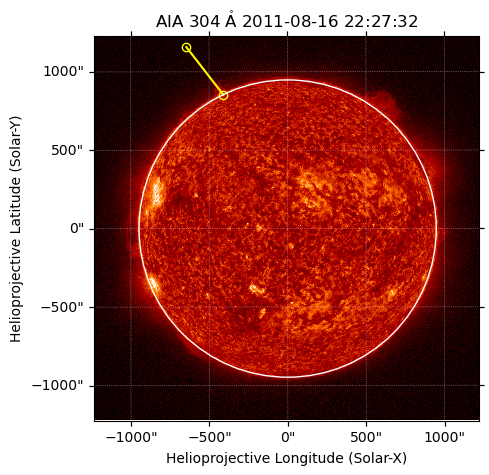

In [6]:

%matplotlib inline
fig2 = plt.figure(figsize=(7, 5))

'''
ax2 = fig2.add_subplot(111, projection=map_small)
map_small.plot( axes=ax2)
'''
ax2 = plt.subplot(projection=example_map)
example_map.plot(axes=ax2,clip_interval=(1, 99.99)*u.percent)
example_map.draw_limb(axes=ax2)
coords = SkyCoord([w0, w1]) 
ax2.plot_coord(coords, color='yellow', lw=1.5)
ax2.plot_coord(coords, 'o', mfc='none', mec='yellow')

plt.savefig('full_image.png')
plt.show()

In [7]:
profiles = []      # [time_index, height_index]
times = []         # astropy Time

for m in sequence_304:
    data = m.data
    # 沿 slit 提取亮度剖面（skimage 的 profile_line）
    # 提取原始剖面
    prof_original = profile_line(data, p0, p1, order=1, mode='reflect')

# 目标采样点数
    N_old = len(prof_original)
    x_old = np.linspace(0, 1, N_old)
    x_new = np.linspace(0, 1, n_samples)

# 插值到统一长度
    prof = np.interp(x_new, x_old, prof_original)
    profiles.append(prof)
    times.append(m.date)   # SunPy map 自带观测时间

profiles = np.array(profiles)  # shape: (N_time, N_height)
times = Time(times)


In [8]:
print(times)

['2011-08-16T22:27:32.120' '2011-08-16T22:33:32.120'
 '2011-08-16T22:39:32.130' '2011-08-16T22:45:32.130'
 '2011-08-16T22:51:32.130' '2011-08-16T22:57:32.130'
 '2011-08-16T23:03:32.130' '2011-08-16T23:09:32.130'
 '2011-08-16T23:15:32.130' '2011-08-16T23:21:32.130'
 '2011-08-16T23:27:32.130' '2011-08-16T23:33:32.130'
 '2011-08-16T23:39:32.130' '2011-08-16T23:45:32.120'
 '2011-08-16T23:51:32.120' '2011-08-16T23:57:32.120'
 '2011-08-17T00:03:32.130' '2011-08-17T00:09:32.130'
 '2011-08-17T00:15:32.120' '2011-08-17T00:21:32.120'
 '2011-08-17T00:27:32.120' '2011-08-17T00:33:32.130'
 '2011-08-17T00:39:32.120' '2011-08-17T00:45:32.120'
 '2011-08-17T00:51:32.130' '2011-08-17T00:57:32.130'
 '2011-08-17T01:03:32.130' '2011-08-17T01:09:32.130'
 '2011-08-17T01:15:32.130' '2011-08-17T01:21:32.130'
 '2011-08-17T01:27:32.120' '2011-08-17T01:33:32.130'
 '2011-08-17T01:39:32.130' '2011-08-17T01:45:32.130'
 '2011-08-17T01:51:32.130' '2011-08-17T01:57:32.130'
 '2011-08-17T02:03:32.130' '2011-08-17T02:09:3

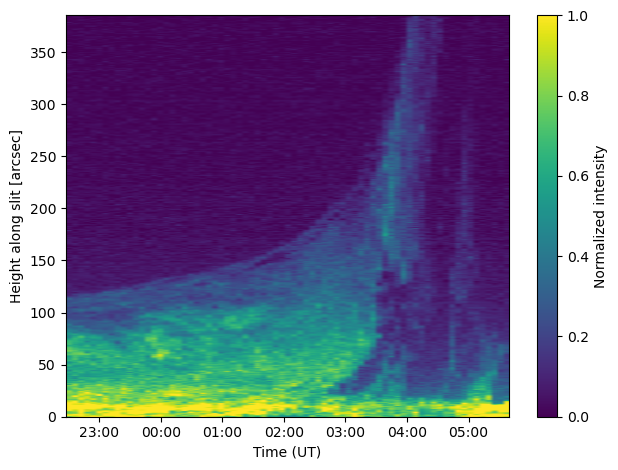

In [9]:
# 高度轴：用 slit 两端的世界坐标距离换算，避免重复计算斜向长度
# w0/w1 来自前一个 pixel_to_world cell，单位是 helioprojective 坐标
slit_length_arcsec = w0.separation(w1).to(u.arcsec).value
height_arcsec = np.linspace(0, slit_length_arcsec, n_samples)

# 保留像素尺度打印/检查用；不再用于 slit 长度主计算
scale_x = example_map.scale[0].to(u.arcsec/u.pixel).value
scale_y = example_map.scale[1].to(u.arcsec/u.pixel).value

%matplotlib inline
t_dt = np.array([t.datetime for t in times])

# 转为 matplotlib 内部时间格式
t_num = mdates.date2num(t_dt)
low, high = np.nanpercentile(profiles, [5, 99])  # 去掉极端值
profiles_clip = np.clip(profiles, low, high)
profiles_norm = (profiles_clip - low) / (high - low)

fig, ax = plt.subplots()
im = ax.imshow(
    profiles_norm.T,
    origin='lower',
    aspect='auto',
    extent=[t_num[0], t_num[-1], height_arcsec[0], height_arcsec[-1]],
)

ax.xaxis_date()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

ax.set_xlabel("Time (UT)")
ax.set_ylabel("Height along slit [arcsec]")

plt.colorbar(im, ax=ax, label="Normalized intensity")
plt.tight_layout()
plt.savefig('orignal_image.png')
plt.savefig('orignal_image.pdf', format='pdf')
plt.show()


In [10]:
%matplotlib qt

t0 = times[0]
t_sec = (times - t0).to(u.s).value

fit_points_file = Path("selected_fit_points_reviewed.csv")
force_reselect_fit = False  # 改成 True 可以重新手选拟合点并覆盖保存的点

if fit_points_file.exists() and not force_reselect_fit:
    saved_points = np.loadtxt(fit_points_file, delimiter=",", skiprows=1)
    saved_points = np.atleast_2d(saved_points)
    t_click_hours = saved_points[:, 0]
    h_click_arcsec = saved_points[:, 1]
    print(f"Loaded {len(t_click_hours)} fit points from {fit_points_file}")
else:
    fig, ax = plt.subplots()
    im = ax.imshow(
        profiles_norm.T,
        origin='lower',
        aspect='auto',
        extent=[t_sec[0]/3600, t_sec[-1]/3600, height_arcsec[0], height_arcsec[-1]],
    )

    ax.set_xlabel('Time since start [hours]')
    ax.set_ylabel('Height along slit [arcsec]')
    plt.colorbar(im, ax=ax, label='Normalized intensity')

    plt.title("在图上依次点击要拟合的点，按 Enter 结束")
    plt.tight_layout()

    pts = plt.ginput(n=-1, timeout=0)
    plt.close(fig)

    print("Clicked points (time[h], height[arcsec]):", pts)

    t_click_hours = np.array([p[0] for p in pts], dtype=float)
    h_click_arcsec = np.array([p[1] for p in pts], dtype=float)

    np.savetxt(
        fit_points_file,
        np.column_stack([t_click_hours, h_click_arcsec]),
        delimiter=",",
        header="time_hours,height_arcsec",
        comments="",
    )
    print(f"Saved {len(t_click_hours)} fit points to {fit_points_file}")

# 拟合前按时间排序，避免点击顺序影响初值和拟合
sort_idx = np.argsort(t_click_hours)
t_click_hours = t_click_hours[sort_idx]
h_click_arcsec = h_click_arcsec[sort_idx]

t_click_sec = t_click_hours * 3600.0
h_click_km = h_click_arcsec * 725.0  # 1 arcsec ~ 725 km
h_click_Mm = h_click_km              # 兼容后续旧变量名；实际单位是 km


Loaded 18 fit points from selected_fit_points_reviewed.csv


[0.27382168 0.58052326 1.05974448 1.48145915 1.84566728 2.19070655
 2.49740813 2.84244741 3.32166863 3.72421445 4.08842258 4.45263071
 4.72099459 4.87434538 5.04686502 5.2385535  5.37273544 5.41107314] [116.61466541 119.61190098 124.6072936  127.60452917 130.60176474
 135.59715736 141.5916285  148.58517816 158.57596339 171.5639842
 187.54924057 205.53265399 225.51422445 248.49303049 274.4690721
 310.43589893 336.41194054 354.39535396]


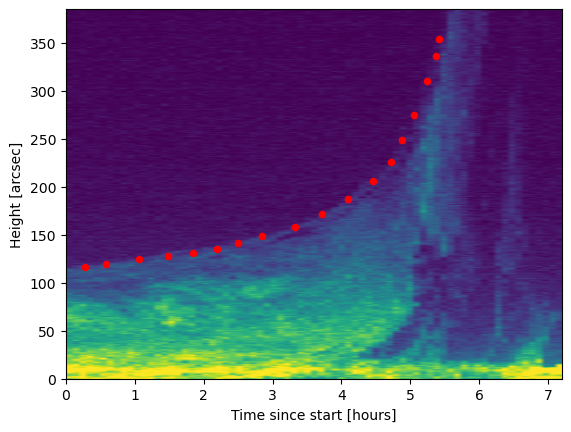

In [11]:

%matplotlib inline
print(t_click_hours, h_click_arcsec)
fig2, ax2 = plt.subplots()
ax2.imshow(profiles_norm.T, origin='lower',
           aspect='auto',
           extent=[t_sec[0]/3600, t_sec[-1]/3600,
                   height_arcsec[0], height_arcsec[-1]])
ax2.scatter(t_click_hours, h_click_arcsec, c='r', s=20)
ax2.set_xlabel('Time since start [hours]')
ax2.set_ylabel('Height [arcsec]')


plt.savefig('select_image.png')
plt.savefig('select_image.pdf',format='pdf')
plt.show()



In [12]:
print(scale_x,scale_y)

0.599419 0.599419


In [13]:
def h_model_fixed_t0(t, c0, tau, c1, c2):
    return c0 * np.exp((t - t_fit[0]) / tau) + c1 * (t - t_fit[0]) + c2

def h_model(t, c0, tau, c1, c2, t0):
    # 保留原函数名，方便后面画图代码继续使用；reviewed 拟合里 t0 固定为 t_fit[0]
    return c0 * np.exp((t - t0) / tau) + c1 * (t - t0) + c2

def v_final(t, c0, tau, c1, t0):
    return c0 * np.exp((t - t0) / tau) / tau + c1


In [14]:
t_fit = t_click_sec          # 秒
h_fit = h_click_km           # km

# 使用排序后的首尾点估计初值
dt = t_fit[-1] - t_fit[0]
dh = h_fit[-1] - h_fit[0]

c1_guess = max(dh / dt * 0.2, 0.0)
c0_guess = max(dh * 0.8, 1.0)
tau_guess = max(dt / 2, 1.0)
c2_guess = h_fit[0] - c0_guess

guess_fixed_t0 = [c0_guess, tau_guess, c1_guess, c2_guess]
print("Initial guess [c0, tau, c1, c2] =", guess_fixed_t0)


Initial guess [c0, tau, c1, c2] = [np.float64(137912.7993564708), np.float64(9247.052632897754), np.float64(1.8642805014679174), np.float64(-53367.16693118334)]


In [15]:
print(t_click_sec)

[  985.75804653  2089.88373404  3815.08012078  5333.2529411
  6644.40219502  7886.54359347  8990.66928098 10232.81067943
 11958.00706616 13407.17203102 14718.32128494 16029.47053886
 16995.58051543 17547.64335918 18168.71405841 18858.7926131
 19341.84760139 19479.86331233]


In [16]:
# 加基本物理约束：c0 > 0, tau > 0；t0 固定为第一帧选点时间，减少参数退化
lower_bounds = [0.0, 1.0, -np.inf, -np.inf]
upper_bounds = [np.inf, np.inf, np.inf, np.inf]

popt_fixed, pcov = curve_fit(
    h_model_fixed_t0,
    t_fit,
    h_fit,
    p0=guess_fixed_t0,
    bounds=(lower_bounds, upper_bounds),
    maxfev=20000,
)

c0, tau, c1, c2 = popt_fixed
t0_param = t_fit[0]
popt = [c0, tau, c1, c2, t0_param]  # 兼容后续画图代码

print("Best-fit parameters [c0, tau, c1, c2, t0_fixed] =")
print(popt)
print('v_final = ', v_final(t_fit[-1], c0, tau, c1, t0_param))


Best-fit parameters [c0, tau, c1, c2, t0_fixed] =
[np.float64(73.48065013759285), np.float64(2475.2572808570067), np.float64(2.2683745585494886), np.float64(83247.91064114969), np.float64(985.7580465314402)]
v_final =  54.43858052581525


In [17]:
# onset 定义：指数项速度 = 线性项速度，即 c0/tau * exp((t-t0)/tau) = c1
if c0 <= 0 or tau <= 0 or c1 <= 0:
    t_break = np.nan
    print("Transition time is undefined for this fit because c0, tau, or c1 is not positive.")
else:
    t_break = t0_param + tau * np.log(c1 * tau / c0)
    print("Transition time (s):", t_break)
    print("Transition time since start (hours):", t_break / 3600)


Transition time (s): 11718.822713839349
Transition time since start (hours): 3.2552285316220413


v_onset: 4.536749117098976
H_onset: 113.20933210949781


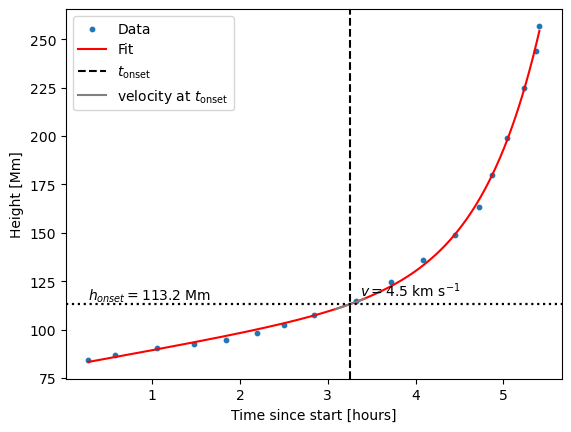

In [18]:
# --- dense curve for plotting ---
t_dense = np.linspace(t_fit[0], t_fit[-1], 500)
h_model_dense = h_model(t_dense, *popt) / 1000  # km -> Mm

fig, ax = plt.subplots()

# --- data + full fit ---
ax.scatter(t_fit/3600, h_fit/1000, s=10, label='Data')
ax.plot(t_dense/3600, h_model_dense, 'r-', label='Fit')

ax.set_xlabel('Time since start [hours]')
ax.set_ylabel('Height [Mm]')

# Only draw onset details when t_break is finite and inside the fitted time range.
plot_onset_details = np.isfinite(t_break) and (t_fit[0] <= t_break <= t_fit[-1])

if plot_onset_details:
    # --- onset time vertical line ---
    ax.axvline(t_break/3600, color='k', ls='--', label=r'$t_{\mathrm{onset}}$')

    # --- split into slow/fast-rise parts (your definition) ---
    t1 = t_dense[t_dense < t_break]
    t2 = t_dense[t_dense >= t_break]

    h_linear = (c1*(t1 - t0_param) + c2 + c0*np.exp((t_break - t0_param)/tau)) / 1000
    h_exp    = (c0*np.exp((t2 - t0_param)/tau) + c2 + c1*(t_break - t0_param)) / 1000

    # Uncomment these if you want the separated slow/fast guide curves on the figure.
    # ax.plot(t1/3600, h_linear, '--', color='tab:blue', label='Slow rise')
    # ax.plot(t2/3600, h_exp, '--', color='tab:orange', label='Impulsive rise')

    # ============================================================
    # NEW (1) Tangent line at t_break + annotate v
    # ============================================================
    h_break = h_model(t_break, *popt)  # km
    v_break = v_final(t_break, c0, tau, c1, t0_param)  # km/s

    # tangent line span
    dt_tan = 10 * 60  # 10 minutes in seconds
    t_tan = np.array([t_break - dt_tan, t_break + dt_tan])
    h_tan = h_break + v_break * (t_tan - t_break)

    ax.plot(
        t_tan/3600,
        h_tan/1000,
        '-',
        color='grey',
        lw=1.5,
        label=r'velocity at $t_{\mathrm{onset}}$',
    )

    x_text = (t_break + dt_tan*0.7) / 3600
    y_text = (h_break + v_break * dt_tan) / 1000

    ax.text(
        x_text, y_text,
        fr"$v={v_break:.1f}$ km s$^{{-1}}$",
        fontsize=10,
        va='bottom',
        ha='left',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0),
    )

    # ============================================================
    # NEW (2) Horizontal dashed line at h(t_break) + label
    # ============================================================
    ax.axhline(h_break/1000, color='k', ls=':', lw=1.6)
    ax.text(
        t_fit[0]/3600,
        h_break/1000,
        fr"$h_{{onset}}={h_break/1000:.1f}$ Mm",
        fontsize=10,
        va='bottom',
        ha='left',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0),
    )

    print('v_onset:', v_break)
    print('H_onset:', h_break/1000)
else:
    print("Onset time is outside the fitted time range or undefined; onset markers were not plotted.")
    print("t_break:", t_break)

# --- final legend (after all lines are added) ---
ax.legend()

plt.savefig('fitting_image.png', dpi=300, bbox_inches='tight')
plt.savefig('fitting_image.pdf', format='pdf', bbox_inches='tight')
plt.show()


In [19]:
# 目标高度：300 Mm -> km
h_target_km = 300 * 1000

def solve_t_at_height(h_target_km, popt, t_min=None, t_max=None, nscan=2000):
    c0, tau, c1, c2, t0 = popt

    if t_min is None:
        t_min = float(np.min(t_fit))
    if t_max is None:
        t_max = float(np.max(t_fit))

    def f(t):
        return h_model(t, c0, tau, c1, c2, t0) - h_target_km

    ts = np.linspace(t_min, t_max, nscan)
    fs = np.array([f(t) for t in ts])

    if np.all(fs < 0):
        raise ValueError("在给定时间范围内，h(t) 始终低于 300 Mm（目标高度不可达）。")
    if np.all(fs > 0):
        raise ValueError("在给定时间范围内，h(t) 始终高于 300 Mm（目标高度在更早时间）。")

    idx = np.where(fs[:-1] * fs[1:] <= 0)[0]
    if len(idx) == 0:
        raise ValueError("扫描未找到符号变化区间，可能需要扩大时间范围或增加 nscan。")

    i = idx[0]
    a, b = ts[i], ts[i+1]
    return brentq(f, a, b)

try:
    t_300 = solve_t_at_height(h_target_km, popt)

    c0, tau, c1, c2, t0_param = popt
    v_300 = v_final(t_300, c0, tau, c1, t0_param)
    h_check = h_model(t_300, *popt) / 1000  # Mm

    print(f"Target height: 300.00 Mm")
    print(f"Solved time t = {t_300:.2f} s  ({t_300/3600:.3f} hr)")
    print(f"Check height h(t) = {h_check:.2f} Mm")
    print(f"Velocity v(t) = {v_300:.2f} km/s")
except ValueError as err:
    print(f"Cannot solve velocity at 300 Mm: {err}")
    print(f"Fitted height range: {h_model(t_fit[0], *popt)/1000:.2f}–{h_model(t_fit[-1], *popt)/1000:.2f} Mm")


Cannot solve velocity at 300 Mm: 在给定时间范围内，h(t) 始终低于 300 Mm（目标高度不可达）。
Fitted height range: 83.32–254.33 Mm


In [20]:
'''
# ============================================================
# Secondary quadratic fitting (separate figure + equation label)
# ============================================================

t_ref = t_fit[0]
x_all = t_fit - t_ref
y_all = h_fit

# quadratic fit
a_q, b_q, c_q = np.polyfit(x_all, y_all, 2)

# ---- 打印结果（保留两位小数） ----
print("Secondary quadratic fitting result:")
print(f"h(t) = {a_q:.2f}(t-{t_ref:.2f})² + {b_q:.2f}(t-{t_ref:.2f}) + {c_q:.2f}")

# dense curve
x_dense_all = t_dense - t_ref
h_quad_dense = (a_q*x_dense_all**2 + b_q*x_dense_all + c_q) / 1000  # Mm

# ---- 新图 ----
fig2, ax2 = plt.subplots(figsize=(6,4))

ax2.scatter(t_fit/3600, h_fit/1000, s=12, label='Data')
ax2.plot(t_dense/3600, h_quad_dense, 'r-', lw=2,
         label='Quadratic fit')

# ---- 在图上标公式 ----
eq_text = (
    fr"$h(t)={a_q:.2f}(t-t_0)^2"
    fr"+{b_q:.2f}(t-t_0)"
    fr"+{c_q:.2f}$"
)

ax2.text(
    0.05, 0.92, eq_text,
    transform=ax2.transAxes,
    fontsize=10,
    verticalalignment='top',
    bbox=dict(facecolor='white', alpha=0.7, edgecolor='none')
)

ax2.set_xlabel('Time since start [hours]')
ax2.set_ylabel('Height [Mm]')
ax2.legend()
ax2.grid(alpha=0.3)

plt.savefig('secondary_quadratic_fit.png', dpi=300, bbox_inches='tight')
plt.savefig('secondary_quadratic_fit.pdf', bbox_inches='tight')
plt.show()
'''



'\n# ============================================================\n# Secondary quadratic fitting (separate figure + equation label)\n# ============================================================\n\nt_ref = t_fit[0]\nx_all = t_fit - t_ref\ny_all = h_fit\n\n# quadratic fit\na_q, b_q, c_q = np.polyfit(x_all, y_all, 2)\n\n# ---- 打印结果（保留两位小数） ----\nprint("Secondary quadratic fitting result:")\nprint(f"h(t) = {a_q:.2f}(t-{t_ref:.2f})² + {b_q:.2f}(t-{t_ref:.2f}) + {c_q:.2f}")\n\n# dense curve\nx_dense_all = t_dense - t_ref\nh_quad_dense = (a_q*x_dense_all**2 + b_q*x_dense_all + c_q) / 1000  # Mm\n\n# ---- 新图 ----\nfig2, ax2 = plt.subplots(figsize=(6,4))\n\nax2.scatter(t_fit/3600, h_fit/1000, s=12, label=\'Data\')\nax2.plot(t_dense/3600, h_quad_dense, \'r-\', lw=2,\n         label=\'Quadratic fit\')\n\n# ---- 在图上标公式 ----\neq_text = (\n    fr"$h(t)={a_q:.2f}(t-t_0)^2"\n    fr"+{b_q:.2f}(t-t_0)"\n    fr"+{c_q:.2f}$"\n)\n\nax2.text(\n    0.05, 0.92, eq_text,\n    transform=ax2.transAxes,\n    fo